# CNN-BiLSTM with FastText

In [ ]:
!pip install dagshub mlflow gensim -q

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D, GlobalAveragePooling1D, SpatialDropout1D, Conv1D, Concatenate, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import regularizers

sns.set_theme(style='whitegrid')
print("Libraries imported.")

# Detect Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub1.2/lentera-ml-research'
    if not os.path.exists(PROJECT_ROOT):
        PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub1.2/lentera-ml-research'
    os.chdir(PROJECT_ROOT)
    print(f"Running in Google Colab. Current dir: {os.getcwd()}")
else:
    # Running locally
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print(f"Running locally. Project root: {PROJECT_ROOT}")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import mlflow
import mlflow.tensorflow
import dagshub

dagshub.init(repo_owner='raflialfansyah', repo_name='lentera1', mlflow=True)
mlflow.set_experiment('CNN_BiLSTM_Urgency')
mlflow.tensorflow.autolog()
mlflow.start_run(run_name='cnnbilstm_Run')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 125.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=684aebd0-c9b4-4dd6-aadd-ae7d7e8859c8&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=3dd9197ebcd4390b2701ec3f892bcb559b2c58315f1f650329cc20d82b3d7ae6




Accessing as raflialfansyah

Initialized MLflow to track repo "raflialfansyah/lentera1"

Repository raflialfansyah/lentera1 initialized!

2026/06/13 16:02:36 INFO mlflow.tracking.fluent: Experiment with name 'CNN_BiLSTM_Urgency' does not exist. Creating a new experiment.


<ActiveRun: >

## 1. Data Loading & Sampling (Balanced 1:1:1)

In [ ]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'cleaned_complaints.csv')
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['Cleaned_Narrative', 'Urgency'])

df_high = df[df['Urgency'] == 'High']
df_medium = df[df['Urgency'] == 'Medium']
df_low = df[df['Urgency'] == 'Low']

min_class_size = df['Urgency'].value_counts().min()

if len(df_high) > min_class_size:
    df_high = df_high.sample(min_class_size, random_state=42)
if len(df_medium) > min_class_size:
    df_medium = df_medium.sample(min_class_size, random_state=42)

df = pd.concat([df_high, df_medium, df_low])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Class Distribution after balanced sampling:")
print(df['Urgency'].value_counts())


Class Distribution after balanced sampling:
Urgency
High      19431
Medium    19431
Low       19431
Name: count, dtype: int64


## 2. Label Encoding & Data Splitting

In [ ]:
label_encoder = LabelEncoder()
df['Urgency_Encoded'] = label_encoder.fit_transform(df['Urgency'])

X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    df['Cleaned_Narrative'], df['Urgency_Encoded'],
    test_size=0.20, random_state=42, stratify=df['Urgency_Encoded']
)
print(f"Train size: {len(X_train_texts)}, Test size: {len(X_test_texts)}")


Train size: 46634, Test size: 11659


## 3. Tokenization & Loading FastText Model

In [ ]:
max_vocab_size = 20000
max_length = 200

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['Cleaned_Narrative'])

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train_texts), maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test_texts), maxlen=max_length, padding='post', truncating='post')

from gensim.models import FastText
ft_model_path = os.path.join(PROJECT_ROOT, 'notebooks', 'fasttext_model_dir', 'fasttext_urgency.model')
print(f"Loading FastText from {ft_model_path}...")
ft_model = FastText.load(ft_model_path)

word_index = tokenizer.word_index
embedding_dim = 200
num_words = min(max_vocab_size, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in word_index.items():
    if i >= max_vocab_size: continue
    try: embedding_matrix[i] = ft_model.wv[word]
    except KeyError: pass
print(f"Embedding matrix shape: {embedding_matrix.shape}")


Loading FastText from /content/drive/MyDrive/lentera-analytics-hub1.2/lentera-ml-research/notebooks/fasttext_model_dir/fasttext_urgency.model...
Embedding matrix shape: (20000, 200)


## 4. Build CNN-BiLSTM Model Architecture

In [ ]:
input_layer = Input(shape=(max_length,), name='Input')
x = Embedding(input_dim=num_words, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False, name='Embedding')(input_layer)
x = SpatialDropout1D(0.3)(x)

# CNN Layer to extract n-gram features locally
x = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same', name='Conv1D')(x)

# BiLSTM for sequence understanding (recurrent_dropout is avoided to force CuDNN GPU backend)
x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3), name='BiLSTM')(x)

# Concatenating Global Average and Global Max Pooling (captures both overall meaning and strong local features)
avg_pool = GlobalAveragePooling1D(name='GlobalAveragePool')(x)
max_pool = GlobalMaxPooling1D(name='GlobalMaxPool')(x)
conc = Concatenate(name='Concatenate')([avg_pool, max_pool])

# Deep Classifier Head
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='Dense1')(conc)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='Dense2')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output_layer = Dense(len(label_encoder.classes_), activation='softmax', name='Output')(x)

model = Model(inputs=input_layer, outputs=output_layer, name='CNN_BiLSTM')
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 200)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 200, 200)  │  4,000,000 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 200, 200)  │          0 │ Embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1D (Conv1D)     │ (None, 200, 128)  │    128,128 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiLSTM              │ (None, 200, 256)  │    263,168 │ Conv1D[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GlobalAveragePool   │ (None, 256)       │          0 │ BiLSTM[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GlobalMaxPool       │ (None, 256)       │          0 │ BiLSTM[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concatenate         │ (None, 512)       │          0 │ GlobalAveragePoo… │
│ (Concatenate)       │                   │            │ GlobalMaxPool[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense1 (Dense)      │ (None, 128)       │     65,664 │ Concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ Dense1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense2 (Dense)      │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ Dense2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 3)         │        195 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,466,179 (17.04 MB)

 Trainable params: 465,795 (1.78 MB)

 Non-trainable params: 4,000,384 (15.26 MB)

## 5. Phase 1 Training (Frozen Embeddings)

In [ ]:
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights_array))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint('cnn_bilstm_phase1.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history_phase1 = model.fit(
    X_train_pad, y_train, epochs=50, batch_size=64,
    validation_data=(X_test_pad, y_test),
    class_weight=class_weights_dict,
    callbacks=callbacks, verbose=1
)


2026/06/13 16:03:38 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


Epoch 1/50
729/729 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5403 - loss: 2.6747
Epoch 1: val_loss improved from None to 0.84078, saving model to cnn_bilstm_phase1.keras

Epoch 1: finished saving model to cnn_bilstm_phase1.keras


729/729 ━━━━━━━━━━━━━━━━━━━━ 48s 53ms/step - accuracy: 0.6217 - loss: 1.7755 - val_accuracy: 0.7152 - val_loss: 0.8408 - learning_rate: 0.0010
Epoch 2/50
729/729 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7330 - loss: 0.7411
Epoch 2: val_loss improved from 0.84078 to 0.58562, saving model to cnn_bilstm_phase1.keras

Epoch 2: finished saving model to cnn_bilstm_phase1.keras


729/729 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.7413 - loss: 0.6895 - val_accuracy: 0.7710 - val_loss: 0.5856 - learning_rate: 0.0010
Epoch 3/50
728/729 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7711 - loss: 0.5976
Epoch 3: val_loss improved from 0.58562 to 0.53044, saving model to cnn_bilstm_phase1.keras

Epoch 3: finished saving model to cnn_bilstm_phase1.keras


729/729 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.7765 - loss: 0.5831 - val_accuracy: 0.7968 - val_loss: 0.5304 - learning_rate: 0.0010
Epoch 4/50
729/729 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7929 - loss: 0.5422
Epoch 4: val_loss improved from 0.53044 to 0.48723, saving model to cnn_bilstm_phase1.keras

Epoch 4: finished saving model to cnn_bilstm_phase1.keras


...

729/729 ━━━━━━━━━━━━━━━━━━━━ 46s 41ms/step - accuracy: 0.8266 - loss: 0.4651 - val_accuracy: 0.8255 - val_loss: 0.4589 - learning_rate: 0.0010
Epoch 10/50
728/729 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8300 - loss: 0.4538
Epoch 10: val_loss improved from 0.45885 to 0.44843, saving model to cnn_bilstm_phase1.keras

Epoch 10: finished saving model to cnn_bilstm_phase1.keras


729/729 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.8308 - loss: 0.4555 - val_accuracy: 0.8304 - val_loss: 0.4484 - learning_rate: 0.0010
Epoch 11/50
728/729 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8360 - loss: 0.4453
Epoch 11: val_loss did not improve from 0.44843
729/729 ━━━━━━━━━━━━━━━━━━━━ 37s 35ms/step - accuracy: 0.8342 - loss: 0.4483 - val_accuracy: 0.8119 - val_loss: 0.5038 - learning_rate: 0.0010
Epoch 12/50
728/729 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8347 - loss: 0.4456
Epoch 12: val_loss did not improve from 0.44843
729/729 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.8361 - loss: 0.4412 - val_accuracy: 0.8271 - val_loss: 0.4748 - learning_rate: 0.0010
Epoch 13/50
728/729 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8421 - loss: 0.4306
Epoch 13: val_loss did not improve from 0.44843

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
729/729 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.8408 - loss: 0.4297 - val_ac

729/729 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.8575 - loss: 0.3854 - val_accuracy: 0.8284 - val_loss: 0.4442 - learning_rate: 5.0000e-04
Epoch 17/50
729/729 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8624 - loss: 0.3743
Epoch 17: val_loss did not improve from 0.44424
729/729 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.8602 - loss: 0.3787 - val_accuracy: 0.8252 - val_loss: 0.4716 - learning_rate: 5.0000e-04
Epoch 18/50
728/729 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8625 - loss: 0.3687
Epoch 18: val_loss did not improve from 0.44424
729/729 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.8613 - loss: 0.3721 - val_accuracy: 0.8306 - val_loss: 0.4472 - learning_rate: 5.0000e-04
Epoch 19/50
729/729 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8662 - loss: 0.3722
Epoch 19: val_loss did not improve from 0.44424

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
729/729 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.8648 - loss: 0.3

729/729 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step - accuracy: 0.8721 - loss: 0.3422 - val_accuracy: 0.8360 - val_loss: 0.4423 - learning_rate: 2.5000e-04
Epoch 22/50
729/729 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8703 - loss: 0.3436
Epoch 22: val_loss did not improve from 0.44235
729/729 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.8722 - loss: 0.3448 - val_accuracy: 0.8362 - val_loss: 0.4484 - learning_rate: 2.5000e-04
Epoch 23/50
729/729 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8776 - loss: 0.3360
Epoch 23: val_loss did not improve from 0.44235
729/729 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.8751 - loss: 0.3389 - val_accuracy: 0.8186 - val_loss: 0.5156 - learning_rate: 2.5000e-04
Epoch 24/50
729/729 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8812 - loss: 0.3255
Epoch 24: val_loss did not improve from 0.44235

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
729/729 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.8788 - loss: 0.3

2026/06/13 16:18:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## 6. Evaluation & Logging

Loaded Phase 1 best weights.
365/365 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.85      0.89      3886
         Low       0.78      0.86      0.82      3886
      Medium       0.81      0.80      0.80      3887

    accuracy                           0.84     11659
   macro avg       0.84      0.84      0.84     11659
weighted avg       0.84      0.84      0.84     11659

Metrics logged to MLflow.


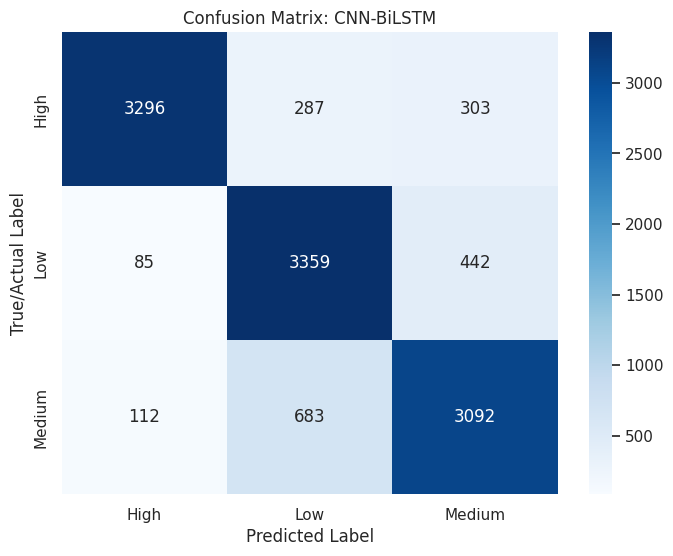

Model artifact logged to DagsHub.
🏃 View run cnnbilstm_Run at: https://dagshub.com/raflialfansyah/lentera1.mlflow/#/experiments/6/runs/31e7e74c08914ab395e0151b02f14510
🧪 View experiment at: https://dagshub.com/raflialfansyah/lentera1.mlflow/#/experiments/6
MLflow run for Phase 1 ended successfully.


In [ ]:
if os.path.exists('cnn_bilstm_phase1.keras'):
    model.load_weights('cnn_bilstm_phase1.keras')
    print("Loaded Phase 1 best weights.")

y_pred_probs_p1 = model.predict(X_test_pad)
y_pred_p1 = np.argmax(y_pred_probs_p1, axis=1)


print("Classification Report:")
print(classification_report(y_test, y_pred_p1, target_names=label_encoder.classes_))

# Log metrics to MLflow
report_p1 = classification_report(y_test, y_pred_p1, target_names=label_encoder.classes_, output_dict=True)
for class_name, metrics in report_p1.items():
    if isinstance(metrics, dict):
        for metric_name, value in metrics.items():
            metric_key = f"{class_name}_{metric_name}".replace(" ", "_").replace("-", "_")
            mlflow.log_metric(metric_key, value)
    else:
        mlflow.log_metric(class_name.replace(" ", "_"), metrics)
print("Metrics logged to MLflow.")

cm_p1 = confusion_matrix(y_test, y_pred_p1)
plt.figure(figsize=(8,6))
sns.heatmap(cm_p1, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True/Actual Label')
plt.title('Confusion Matrix: CNN-BiLSTM')
plt.savefig('cnn_bilstm_phase1_confusion_matrix.png')
mlflow.log_artifact('cnn_bilstm_phase1_confusion_matrix.png', artifact_path='evaluation_plots')
plt.show()

# Akhiri logging eksperimen Phase 1
if os.path.exists('cnn_bilstm_phase1.keras'):
    mlflow.log_artifact('cnn_bilstm_phase1.keras', artifact_path='models')
    print('Model artifact logged to DagsHub.')
mlflow.end_run()
print("MLflow run for Phase 1 ended successfully.")